In [1]:
from pathlib import Path

In [3]:
df= pd.read_csv(Path("outputs") / "df.csv")

In [4]:
df= pd.read_csv(Path("outputs") / "df.csv")
df_busan= pd.read_csv(Path("outputs") / "df_busan.csv")

In [2]:
# ============================================================
# Case 4 Notebook Block: Sensitivity & Robustness
#   - Endpoint sensitivity (Busan vs Yokohama)
#   - Equal-speed sensitivity
#   - Exports LaTeX tables + figures
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# ----------------------------
# 0) Settings
# ----------------------------
OUTDIR = "figures"
TABDIR = "tables"
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(TABDIR, exist_ok=True)

CORRIDOR_ORDER = ["NSR", "SUEZ", "CAPE"]     # keep consistent with paper
VARIANT_ORDER  = ["service", "bluewater", "coast"]

# Representative corridor speeds (kn) used in Case 2
SPEEDS = {"NSR": 12.5, "SUEZ": 14.5, "CAPE": 14.0}
EQUAL_SPEED = 14.0  # apples-to-apples check

# ----------------------------
# 1) Helper: clean LaTeX export (tabular only, no table env)
# ----------------------------
def export_tabular_latex(df, path, float_fmt="%.2f"):
    tex = df.to_latex(index=False, escape=False, float_format=float_fmt)
    with open(path, "w", encoding="utf-8") as f:
        f.write(tex)


In [6]:
# --- Build properly aligned endpoint-sensitivity table (SEA-only) ---

# 1) Yokohama SEA-only distances
sea_yok = (df.query("method == 'SEA'")
             .loc[:, ["corridor", "variant", "distance_knm"]]
             .rename(columns={"distance_knm": "Yokohama (k nm)"}))

# 2) Busan SEA-only distances (computed analogously)
sea_bus = (df_busan.query("method == 'SEA'")
              .loc[:, ["corridor", "variant", "distance_knm"]]
              .rename(columns={"distance_knm": "Busan (k nm)"}))

# 3) Merge on corridor + variant (critical!)
delta_df_tbl = (sea_yok.merge(sea_bus, on=["corridor", "variant"], how="inner"))

# 4) Add delta columns
delta_df_tbl["Δ (k nm)"]   = delta_df_tbl["Busan (k nm)"] - delta_df_tbl["Yokohama (k nm)"]
delta_df_tbl["Δ (%)"]      = 100 * delta_df_tbl["Δ (k nm)"] / delta_df_tbl["Yokohama (k nm)"]

# 5) Sort for nice plotting (CAPE, NSR, SUEZ and service/bluewater/coast)
corr_order = ["SUEZ", "NSR", "CAPE"]
var_order  = ["service", "bluewater", "coast"]

delta_df_tbl["corridor"] = pd.Categorical(delta_df_tbl["corridor"], corr_order, ordered=True)
delta_df_tbl["variant"]  = pd.Categorical(delta_df_tbl["variant"],  var_order,  ordered=True)
delta_df_tbl = delta_df_tbl.sort_values(["corridor", "variant"]).reset_index(drop=True)

delta_df_tbl

,corridor,variant,Yokohama (k nm),Busan (k nm),Δ (k nm),Δ (%)
0,SUEZ,service,11.545575,12.184332,0.638757,5.532486
1,SUEZ,bluewater,11.981478,12.620235,0.638757,5.331206
2,SUEZ,coast,11.703988,12.342746,0.638757,5.457604
3,NSR,service,8.642788,9.281545,0.638757,7.390639
4,NSR,bluewater,8.612982,9.251739,0.638757,7.416215
5,NSR,coast,8.588469,9.227227,0.638757,7.437382
6,CAPE,service,15.803021,16.441778,0.638757,4.041995
7,CAPE,bluewater,16.051906,16.690663,0.638757,3.979324
8,CAPE,coast,16.073355,16.712112,0.638757,3.974013


In [7]:
# ----------------------------
# 3) Corridor medians to Busan (Table: DEST_BUSAN_SEA_corridor_medians.tex)
# ----------------------------
bus_medians = (sea_bus
               .groupby("corridor", observed=True)["distance_nm"]
               .agg(["median","min","max","std"])
               .reset_index())

bus_medians["CV (%)"] = 100 * bus_medians["std"] / bus_medians["median"]
bus_medians["Median (k nm)"] = bus_medians["median"] / 1000
bus_medians["Min (k nm)"]    = bus_medians["min"] / 1000
bus_medians["Max (k nm)"]    = bus_medians["max"] / 1000

bus_medians_tbl = bus_medians[[
    "corridor","Median (k nm)","Min (k nm)","Max (k nm)","std","CV (%)"
]].sort_values("corridor")

export_tabular_latex(
    bus_medians_tbl,
    os.path.join(TABDIR, "DEST_BUSAN_SEA_corridor_medians.tex"),
    float_fmt="%.2f"
)
display(bus_medians_tbl)

KeyError: 'Column not found: distance_nm'

In [15]:
# ----------------------------
# 4) Per-variant distances to Busan (Table: DEST_BUSAN_SEA_per_variant.tex)
# ----------------------------
bus_per_variant = (sea_bus
                   .pivot_table(index=["corridor","variant"],
                                values="distance_nm",
                                aggfunc="first")
                   .reset_index())

bus_per_variant["Sea-only (k nm)"] = bus_per_variant["distance_nm"] / 1000
bus_per_variant_tbl = (bus_per_variant[["corridor","variant","Sea-only (k nm)"]]
                       .sort_values(["corridor","variant"]))

export_tabular_latex(
    bus_per_variant_tbl,
    os.path.join(TABDIR, "DEST_BUSAN_SEA_per_variant.tex"),
    float_fmt="%.2f"
)
display(bus_per_variant_tbl)

/var/folders/6_/4517vxws0wq2qfxj8hkfdgdm0000gp/T/ipykernel_95393/174829465.py:20: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  tex = df.to_latex(index=False, escape=False, float_format=float_fmt)


,corridor,variant,Sea-only (k nm)
0,NSR,service,9.281545
1,NSR,bluewater,9.251739
2,NSR,coast,9.227227
3,SUEZ,service,12.184332
4,SUEZ,bluewater,12.620235
5,SUEZ,coast,12.342746
6,CAPE,service,16.441778
7,CAPE,bluewater,16.690663
8,CAPE,coast,16.712112


In [16]:
# ----------------------------
# 5) Delta vs baseline destination (Busan − Yokohama)
#     Table: DEST_DELTA_vs_baseline_SEA.tex
# ----------------------------
# align baseline and busan by corridor+variant
yok_keyed = sea_yok.set_index(["corridor","variant"])["distance_nm"]
bus_keyed = sea_bus.set_index(["corridor","variant"])["distance_nm"]

delta_df = pd.DataFrame({
    "corridor": [idx[0] for idx in yok_keyed.index],
    "variant":  [idx[1] for idx in yok_keyed.index],
    "Yokohama (k nm)": yok_keyed.values / 1000,
    "Busan (k nm)":    bus_keyed.values / 1000
})

delta_df["Δ (k nm)"]    = delta_df["Busan (k nm)"] - delta_df["Yokohama (k nm)"]
delta_df["Δ (%)"]       = 100 * delta_df["Δ (k nm)"] / delta_df["Yokohama (k nm)"]

delta_df_tbl = (delta_df
                .sort_values(["corridor","variant"])
                .reset_index(drop=True))

export_tabular_latex(
    delta_df_tbl,
    os.path.join(TABDIR, "DEST_DELTA_vs_baseline_SEA.tex"),
    float_fmt="%.2f"
)
display(delta_df_tbl)

/var/folders/6_/4517vxws0wq2qfxj8hkfdgdm0000gp/T/ipykernel_95393/174829465.py:20: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  tex = df.to_latex(index=False, escape=False, float_format=float_fmt)


,corridor,variant,Yokohama (k nm),Busan (k nm),Δ (k nm),Δ (%)
0,CAPE,bluewater,16.051906,9.251739,-6.800166,-42.363608
1,CAPE,coast,16.073355,9.227227,-6.846128,-42.593026
2,CAPE,service,15.803021,9.281545,-6.521475,-41.267270
3,NSR,bluewater,8.612982,16.690663,8.077681,93.784953
4,NSR,coast,8.588469,16.712112,8.123643,94.587782
5,NSR,service,8.642788,16.441778,7.798990,90.236966
6,SUEZ,bluewater,11.981478,12.620235,0.638757,5.331206
7,SUEZ,coast,11.703988,12.342746,0.638757,5.457604
8,SUEZ,service,11.545575,12.184332,0.638757,5.532486


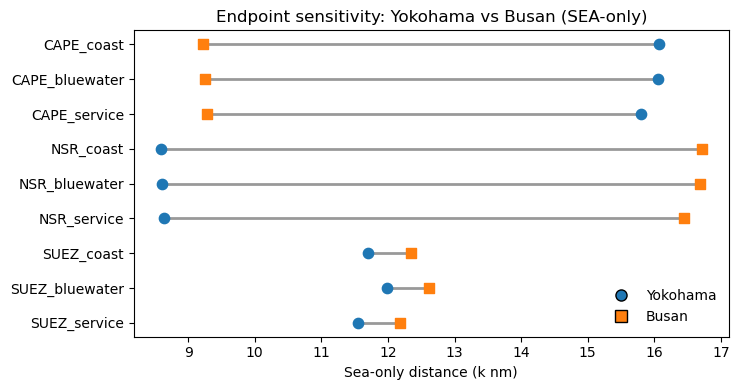

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os

# ----------------------------
# 6) Figure A: Endpoint sensitivity dumbbell (Busan vs Yokohama)
# ----------------------------
c_yok = "tab:blue"
c_bus = "tab:orange"
c_line = "0.6"  # neutral gray

delta_df_tbl = delta_df_tbl.sort_values(
    by=["corridor","variant"],
    key=lambda s: s.map({"SUEZ":0,"NSR":1,"CAPE":2,"service":0,"bluewater":1,"coast":2}).fillna(s)
).reset_index(drop=True)

plt.figure(figsize=(7.5, 4))
ypos = np.arange(len(delta_df_tbl))

for i, row in delta_df_tbl.iterrows():
    x1 = row["Yokohama (k nm)"]
    x2 = row["Busan (k nm)"]

    # neutral connector line
    plt.plot([x1, x2], [i, i], color=c_line, linewidth=2, zorder=1)

    # fixed colors for endpoints
    plt.scatter([x1], [i], marker="o", s=55, color=c_yok, zorder=2)
    plt.scatter([x2], [i], marker="s", s=55, color=c_bus, zorder=2)

labels = [f"{r.corridor}_{r.variant}" for r in delta_df_tbl.itertuples()]
plt.yticks(ypos, labels)
plt.xlabel("Sea-only distance (k nm)")
plt.title("Endpoint sensitivity: Yokohama vs Busan (SEA-only)")

# proxy artists for a stable legend
handles = [
    Line2D([0],[0], marker="o", color="none", markerfacecolor=c_yok,
           markersize=8, label="Yokohama"),
    Line2D([0],[0], marker="s", color="none", markerfacecolor=c_bus,
           markersize=8, label="Busan")
]
plt.legend(handles=handles, frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "DEST_endpoint_sensitivity_dumbbell.png"), dpi=300)
plt.show()

In [20]:
# ----------------------------
# 7) Equal-speed sensitivity (apples-to-apples)
#     Uses SEA-only Yokohama distances; recompute time at common speed
# ----------------------------
sea_yok_eq = sea_yok.copy()
sea_yok_eq["time_days_corridor_speed"] = (sea_yok_eq["distance_nm"] / sea_yok_eq["corridor"].map(SPEEDS)) / 24
sea_yok_eq["time_days_equal_speed"]    = (sea_yok_eq["distance_nm"] / EQUAL_SPEED) / 24

eq_summary = (sea_yok_eq
              .groupby("corridor", observed=True)
              .agg(dist_med_knm=("distance_nm", lambda x: np.median(x)/1000),
                   days_med_corr=("time_days_corridor_speed","median"),
                   days_med_equal=("time_days_equal_speed","median"))
              .reindex(CORRIDOR_ORDER)
              .reset_index())

display(eq_summary)

TypeError: Object with dtype category cannot perform the numpy op divide

In [19]:
# Figure B: corridor median days (corridor speed vs equal speed)
plt.figure(figsize=(6.5, 3.8))
x = np.arange(len(CORRIDOR_ORDER))
w = 0.35

plt.bar(x - w/2, eq_summary["days_med_corr"], width=w, label="Corridor-typical speed")
plt.bar(x + w/2, eq_summary["days_med_equal"], width=w, label=f"Equal speed ({EQUAL_SPEED} kn)")
plt.xticks(x, CORRIDOR_ORDER)
plt.ylabel("Median indicative duration (days)")
plt.title("Equal-speed sensitivity (SEA-only distances)")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "BASELINE_equal_speed_days_bars.png"), dpi=300)
plt.show()

print("Case 4 outputs written to:")
print("  tables/DEST_BUSAN_SEA_corridor_medians.tex")
print("  tables/DEST_BUSAN_SEA_per_variant.tex")
print("  tables/DEST_DELTA_vs_baseline_SEA.tex")
print("  figures/DEST_endpoint_sensitivity_dumbbell.png")
print("  figures/BASELINE_equal_speed_days_bars.png")

NameError: name 'eq_summary' is not defined

<Figure size 650x380 with 0 Axes>

In [3]:
# ============================================================
# Case 4 Notebook Block: Sensitivity & Robustness
#   - Endpoint sensitivity (Busan vs Yokohama)
#   - Equal-speed sensitivity
#   - Exports LaTeX tables + figures
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
df= pd.read_csv(Path("outputs") / "df.csv")
df_busan= pd.read_csv(Path("outputs") / "df_busan.csv")

In [5]:
# ----------------------------
# 0) Settings
# ----------------------------
OUTDIR = "figures"
TABDIR = "tables"
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(TABDIR, exist_ok=True)

CORRIDOR_ORDER = ["NSR", "SUEZ", "CAPE"]     # keep consistent with paper
VARIANT_ORDER  = ["service", "bluewater", "coast"]

# Representative corridor speeds (kn) used in Case 2
SPEEDS = {"NSR": 12.5, "SUEZ": 14.5, "CAPE": 14.0}
EQUAL_SPEED = 14.0  # apples-to-apples check


In [6]:
# ----------------------------
# 1) Helper: clean LaTeX export (tabular only, no table env)
# ----------------------------
def export_tabular_latex(df, path, float_fmt="%.2f"):
    tex = df.to_latex(index=False, escape=False, float_format=float_fmt)
    with open(path, "w", encoding="utf-8") as f:
        f.write(tex)

In [8]:
# ----------------------------
# 2) Extract SEA-only baseline + Busan results
# ----------------------------
sea_yok = df[df["method"] == "SEA"].copy()
sea_yok["endpoint"] = "YOKOHAMA"

# df_busan must be computed in the same way as df, but with Busan as destination
sea_bus = df_busan[df_busan["method"] == "SEA"].copy()
sea_bus["endpoint"] = "BUSAN"

# ensure consistent ordering categories
sea_yok["corridor"] = pd.Categorical(sea_yok["corridor"], CORRIDOR_ORDER, ordered=True)
sea_bus["corridor"] = pd.Categorical(sea_bus["corridor"], CORRIDOR_ORDER, ordered=True)
sea_yok["variant"]  = pd.Categorical(sea_yok["variant"], VARIANT_ORDER, ordered=True)
sea_bus["variant"]  = pd.Categorical(sea_bus["variant"], VARIANT_ORDER, ordered=True)


In [9]:
# ----------------------------
# 3) Corridor medians to Busan (Table: DEST_BUSAN_SEA_corridor_medians.tex)
# ----------------------------
bus_medians = (sea_bus
               .groupby("corridor", observed=True)["distance_nm"]
               .agg(["median","min","max","std"])
               .reset_index())

bus_medians["CV (%)"] = 100 * bus_medians["std"] / bus_medians["median"]
bus_medians["Median (k nm)"] = bus_medians["median"] / 1000
bus_medians["Min (k nm)"]    = bus_medians["min"] / 1000
bus_medians["Max (k nm)"]    = bus_medians["max"] / 1000

bus_medians_tbl = bus_medians[[
    "corridor","Median (k nm)","Min (k nm)","Max (k nm)","std","CV (%)"
]].sort_values("corridor")

export_tabular_latex(
    bus_medians_tbl,
    os.path.join(TABDIR, "DEST_BUSAN_SEA_corridor_medians.tex"),
    float_fmt="%.2f"
)
display(bus_medians_tbl)

/var/folders/6_/4517vxws0wq2qfxj8hkfdgdm0000gp/T/ipykernel_45426/3661320805.py:5: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  tex = df.to_latex(index=False, escape=False, float_format=float_fmt)


,corridor,Median (k nm),Min (k nm),Max (k nm),std,CV (%)
0,NSR,9.251739,9.227227,9.281545,27.202347,0.294024
1,SUEZ,12.342746,12.184332,12.620235,220.645576,1.787654
2,CAPE,16.690663,16.441778,16.712112,150.268865,0.900317


In [10]:
# ----------------------------
# 4) Per-variant distances to Busan (Table: DEST_BUSAN_SEA_per_variant.tex)
# ----------------------------
bus_per_variant = (sea_bus
                   .pivot_table(index=["corridor","variant"],
                                values="distance_nm",
                                aggfunc="first")
                   .reset_index())

bus_per_variant["Sea-only (k nm)"] = bus_per_variant["distance_nm"] / 1000
bus_per_variant_tbl = (bus_per_variant[["corridor","variant","Sea-only (k nm)"]]
                       .sort_values(["corridor","variant"]))

export_tabular_latex(
    bus_per_variant_tbl,
    os.path.join(TABDIR, "DEST_BUSAN_SEA_per_variant.tex"),
    float_fmt="%.2f"
)
display(bus_per_variant_tbl)

/var/folders/6_/4517vxws0wq2qfxj8hkfdgdm0000gp/T/ipykernel_45426/3661320805.py:5: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  tex = df.to_latex(index=False, escape=False, float_format=float_fmt)


,corridor,variant,Sea-only (k nm)
0,NSR,service,9.281545
1,NSR,bluewater,9.251739
2,NSR,coast,9.227227
3,SUEZ,service,12.184332
4,SUEZ,bluewater,12.620235
5,SUEZ,coast,12.342746
6,CAPE,service,16.441778
7,CAPE,bluewater,16.690663
8,CAPE,coast,16.712112


In [11]:
# ----------------------------
# 5) Delta vs baseline destination (Busan − Yokohama)
#     Table: DEST_DELTA_vs_baseline_SEA.tex
# ----------------------------
# align baseline and busan by corridor+variant
yok_keyed = sea_yok.set_index(["corridor","variant"])["distance_nm"]
bus_keyed = sea_bus.set_index(["corridor","variant"])["distance_nm"]

delta_df = pd.DataFrame({
    "corridor": [idx[0] for idx in yok_keyed.index],
    "variant":  [idx[1] for idx in yok_keyed.index],
    "Yokohama (k nm)": yok_keyed.values / 1000,
    "Busan (k nm)":    bus_keyed.values / 1000
})

delta_df["Δ (k nm)"]    = delta_df["Busan (k nm)"] - delta_df["Yokohama (k nm)"]
delta_df["Δ (%)"]       = 100 * delta_df["Δ (k nm)"] / delta_df["Yokohama (k nm)"]

delta_df_tbl = (delta_df
                .sort_values(["corridor","variant"])
                .reset_index(drop=True))

export_tabular_latex(
    delta_df_tbl,
    os.path.join(TABDIR, "DEST_DELTA_vs_baseline_SEA.tex"),
    float_fmt="%.2f"
)
display(delta_df_tbl)

/var/folders/6_/4517vxws0wq2qfxj8hkfdgdm0000gp/T/ipykernel_45426/3661320805.py:5: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  tex = df.to_latex(index=False, escape=False, float_format=float_fmt)


,corridor,variant,Yokohama (k nm),Busan (k nm),Δ (k nm),Δ (%)
0,CAPE,bluewater,16.051906,9.251739,-6.800166,-42.363608
1,CAPE,coast,16.073355,9.227227,-6.846128,-42.593026
2,CAPE,service,15.803021,9.281545,-6.521475,-41.267270
3,NSR,bluewater,8.612982,16.690663,8.077681,93.784953
4,NSR,coast,8.588469,16.712112,8.123643,94.587782
5,NSR,service,8.642788,16.441778,7.798990,90.236966
6,SUEZ,bluewater,11.981478,12.620235,0.638757,5.331206
7,SUEZ,coast,11.703988,12.342746,0.638757,5.457604
8,SUEZ,service,11.545575,12.184332,0.638757,5.532486


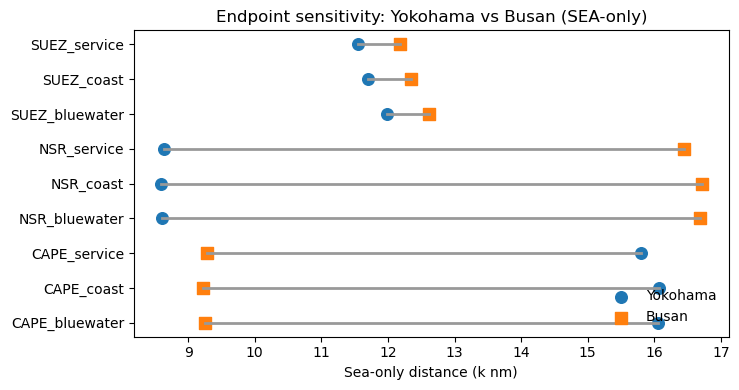

In [13]:
# ----------------------------
# 6) Figure A: Endpoint sensitivity dumbbell (Busan vs Yokohama)
# ----------------------------

plt.figure(figsize=(7.5, 4))
ypos = np.arange(len(delta_df_tbl))

for i, row in delta_df_tbl.iterrows():
    x1 = row["Yokohama (k nm)"]
    x2 = row["Busan (k nm)"]

    # connecting line
    plt.plot([x1, x2], [i, i], color="0.6", linewidth=2)

    # fixed marker colors
    plt.scatter([x1], [i], marker="o", s=70, color="tab:blue",
                label="Yokohama" if i==0 else None)
    plt.scatter([x2], [i], marker="s", s=70, color="tab:orange",
                label="Busan" if i==0 else None)

labels = [f"{r.corridor}_{r.variant}" for r in delta_df_tbl.itertuples()]
plt.yticks(ypos, labels)

plt.xlabel("Sea-only distance (k nm)")
plt.title("Endpoint sensitivity: Yokohama vs Busan (SEA-only)")
plt.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "DEST_endpoint_sensitivity_dumbbell.png"), dpi=300)
plt.show()

In [1]:
# ============================================================
# Case 4 — Sensitivity & robustness
#  A) Endpoint sensitivity (Yokohama vs Busan) on SEA-only distances
#  B) Equal-speed sensitivity (apples-to-apples) on SEA-only Yokohama distances
#
# Produces:
#  - df_busan (GC + SEA distances)
#  - DEST_BUSAN_SEA_corridor_medians.tex
#  - DEST_BUSAN_SEA_per_variant.tex
#  - DEST_DELTA_vs_baseline_SEA.tex
#  - DEST_endpoint_sensitivity_dumbbell.png
#  - BASELINE_equal_speed_days_bars.png
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Loaded WAYPOINTS with explicit philosophies:
SUEZ
   VAR1_service -> Service-guided: approximates typical liner/bulk trunk logic via major hubs & chokepoints.
   VAR2_bluewater -> Bluewater-oriented: favors longer open-ocean legs and fewer coastal/strait constraints where feasible.
   VAR3_coast -> Coast/channel-guided: adheres more closely to constrained lanes, straits, and coastal guidance.
CAPE
   VAR1_service -> Service-guided: approximates typical liner/bulk trunk logic via major hubs & chokepoints.
   VAR2_bluewater -> Bluewater-oriented: favors longer open-ocean legs and fewer coastal/strait constraints where feasible.
   VAR3_coast -> Coast/channel-guided: adheres more closely to constrained lanes, straits, and coastal guidance.
NSR
   VAR1_service -> Service-guided: approximates typical liner/bulk trunk logic via major hubs & chokepoints.
   VAR2_bluewater -> Bluewater-oriented: favors longer open-ocean legs and fewer coastal/strait constraints where feasible.
   VAR3_coast ->

/var/folders/6_/4517vxws0wq2qfxj8hkfdgdm0000gp/T/ipykernel_58667/805306817.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  df_manifest.to_latex("tables/waypoint_manifest.tex", index=False)


WARN: suspicious searoute leg (35.0, 140.0)->(35.45, 139.65): poly=31.9 nm, gc=32.0 nm; using GC.
WARN: suspicious searoute leg (35.0, 140.0)->(35.45, 139.65): poly=31.9 nm, gc=32.0 nm; using GC.
WARN: suspicious searoute leg (-25.0, 35.0)->(-20.0, 40.0): poly=313.6 nm, gc=408.0 nm; using GC.
WARN: suspicious searoute leg (35.0, 140.0)->(35.45, 139.65): poly=31.9 nm, gc=32.0 nm; using GC.
WARN: suspicious searoute leg (72.0, 160.0)->(69.0, 179.6): poly=15778.1 nm, gc=431.3 nm; using GC.
WARN: suspicious searoute leg (69.0, 179.6)->(69.0, -179.6): poly=0.0 nm, gc=17.3 nm; using GC.
WARN: suspicious searoute leg (69.0, -179.6)->(66.0, -169.0): poly=3601.6 nm, gc=303.4 nm; using GC.
WARN: suspicious searoute leg (54.5, 179.6)->(54.5, -179.6): poly=424.5 nm, gc=28.0 nm; using GC.
WARN: suspicious searoute leg (35.0, 140.0)->(35.45, 139.65): poly=31.9 nm, gc=32.0 nm; using GC.
WARN: suspicious searoute leg (73.0, 150.0)->(69.5, 179.6): poly=15641.9 nm, gc=603.5 nm; using GC.
WARN: suspiciou

/var/folders/6_/4517vxws0wq2qfxj8hkfdgdm0000gp/T/ipykernel_58667/3346242615.py:28: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  tex_tbl.to_latex(
/var/folders/6_/4517vxws0wq2qfxj8hkfdgdm0000gp/T/ipykernel_58667/2268787062.py:25: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  med_tbl.to_latex(


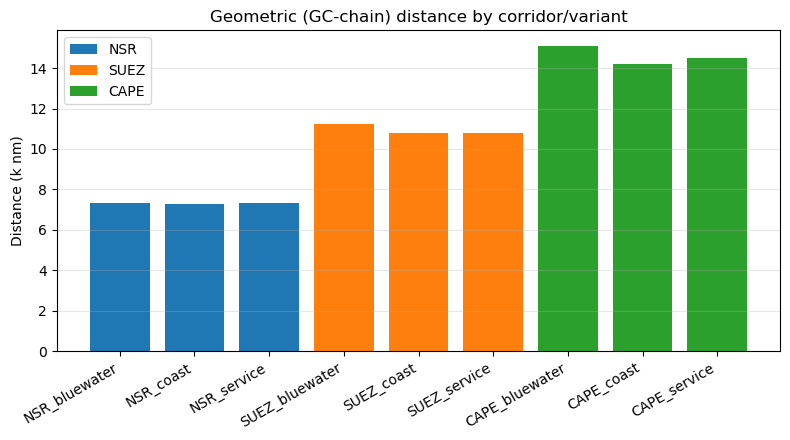

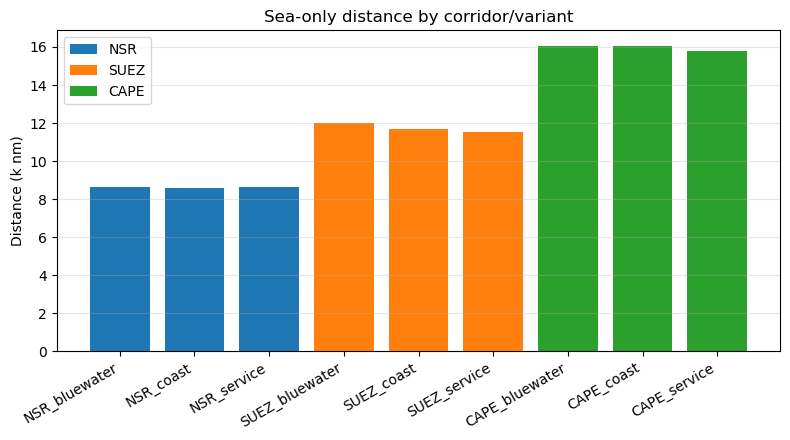

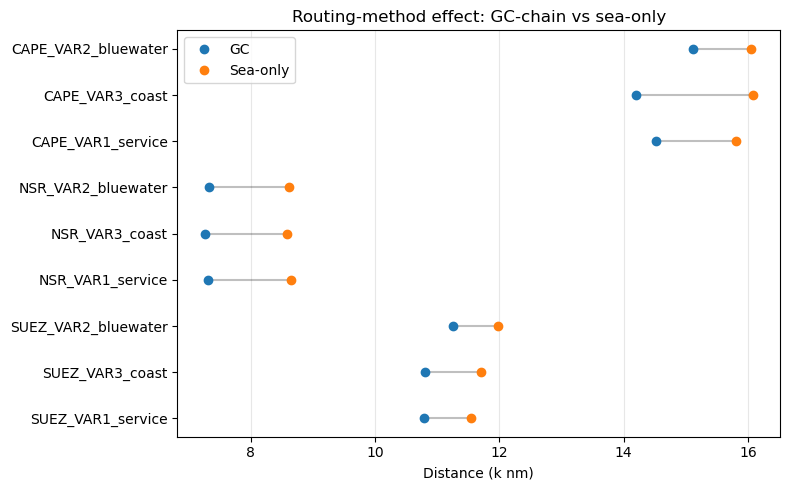

Warnings saved to: logs/warnings_case01.txt

Done. Produced:
- tables/BASELINE_all.csv
- tables/BASELINE_all.tex
- tables/BASELINE_corridor_medians.csv
- tables/BASELINE_corridor_medians.tex
- figures/case01_distance_bars_gc.png
- figures/BASELINE_distance.png
- figures/BASELINE_gc_vs_sea_dumbbell.png
- logs/warnings_case01.txt


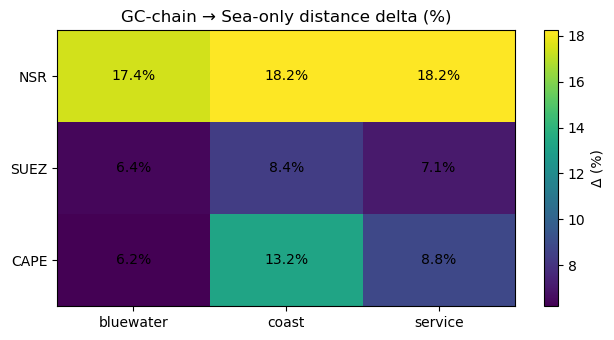

Wrote: figures/BASELINE_delta_heatmap_pct.png


NameError: name 'OUT' is not defined

NameError: name 'OUT' is not defined

In [6]:
%run "Case01_distances.ipynb"

In [8]:
# ----------------------------
# 0) Safety checks + constants
# ----------------------------
assert "SCENARIOS" in globals(), "SCENARIOS dict not found. Run Case 1 notebook first."
assert "df" in globals(), "df (Yokohama) not found. Run Case 1 notebook first."

BUSAN = (35.1028, 129.0403)

CORRIDOR_ORDER = ["SUEZ", "NSR", "CAPE"]
VARIANT_ORDER  = ["service", "bluewater", "coast"]

# Corridor-typical speeds (kn) consistent with Table params + paper
SPEEDS = {"NSR": 12.5, "SUEZ": 14.5, "CAPE": 14.0}
EQUAL_SPEED = 14.0  # apples-to-apples speed

OUTDIR = globals().get("OUTDIR", "figures")
os.makedirs(OUTDIR, exist_ok=True)


In [9]:
# ----------------------------
# 1) Build Busan scenarios
# ----------------------------
SCENARIOS_BUSAN = {}
for scen_key, wpts in SCENARIOS.items():
    SCENARIOS_BUSAN[scen_key] = list(wpts[:-1]) + [BUSAN]


In [10]:
# ----------------------------
# 2) Recompute GC-chain and SEA-only for Busan
# ----------------------------
records_busan = []
routes_gc_busan = {}
routes_sea_busan = {}

for scen_key, wpts in SCENARIOS_BUSAN.items():
    corr = corridor_of(scen_key)
    variant = scen_key.split("_")[-1]

    wpts_guarded = insert_dateline_guards(wpts)

    # GC-chain distance
    gc_poly = wpts_guarded[:]
    gc_dist_nm = polyline_nm(gc_poly)
    routes_gc_busan[scen_key] = gc_poly

    records_busan.append(dict(
        scenario=scen_key, corridor=corr, variant=variant,
        method="GC", distance_nm=gc_dist_nm
    ))

    # SEA-only distance
    sea_poly_all = [wpts_guarded[0]]
    sea_dist_total_nm = 0.0

    for a, b in zip(wpts_guarded[:-1], wpts_guarded[1:]):
        leg_poly, leg_nm = sea_leg_with_guard(a, b)
        sea_dist_total_nm += leg_nm
        sea_poly_all.extend(leg_poly[1:])

    routes_sea_busan[scen_key] = sea_poly_all

    records_busan.append(dict(
        scenario=scen_key, corridor=corr, variant=variant,
        method="SEA", distance_nm=sea_dist_total_nm
    ))

df_busan = pd.DataFrame(records_busan)
df_busan["distance_knm"] = df_busan["distance_nm"] / 1000.0

WARN: suspicious searoute leg (-25.0, 35.0)->(-20.0, 40.0): poly=313.6 nm, gc=408.0 nm; using GC.
WARN: suspicious searoute leg (72.0, 160.0)->(69.0, 179.6): poly=15778.1 nm, gc=431.3 nm; using GC.
WARN: suspicious searoute leg (69.0, 179.6)->(69.0, -179.6): poly=0.0 nm, gc=17.3 nm; using GC.
WARN: suspicious searoute leg (69.0, -179.6)->(66.0, -169.0): poly=3601.6 nm, gc=303.4 nm; using GC.
WARN: suspicious searoute leg (54.5, 179.6)->(54.5, -179.6): poly=424.5 nm, gc=28.0 nm; using GC.
WARN: suspicious searoute leg (73.0, 150.0)->(69.5, 179.6): poly=15641.9 nm, gc=603.5 nm; using GC.
WARN: suspicious searoute leg (69.5, 179.6)->(69.5, -179.6): poly=0.0 nm, gc=16.9 nm; using GC.
WARN: suspicious searoute leg (69.5, -179.6)->(66.0, -169.0): poly=3601.6 nm, gc=320.1 nm; using GC.
WARN: suspicious searoute leg (54.5, 179.6)->(54.5, -179.6): poly=424.5 nm, gc=28.0 nm; using GC.
WARN: suspicious searoute leg (71.0, 165.0)->(68.5, 179.6): poly=15912.8 nm, gc=338.7 nm; using GC.
WARN: suspic

In [11]:
df_busan

,scenario,corridor,variant,method,distance_nm,distance_knm
0,SUEZ_VAR1_service,SUEZ,service,GC,11289.236576,11.289237
1,SUEZ_VAR1_service,SUEZ,service,SEA,12184.331974,12.184332
2,SUEZ_VAR2_bluewater,SUEZ,bluewater,GC,11766.204245,11.766204
3,SUEZ_VAR2_bluewater,SUEZ,bluewater,SEA,12620.235085,12.620235
4,SUEZ_VAR3_coast,SUEZ,coast,GC,11305.859734,11.305860
5,SUEZ_VAR3_coast,SUEZ,coast,SEA,12342.745566,12.342746
6,CAPE_VAR1_service,CAPE,service,GC,15031.988970,15.031989
7,CAPE_VAR1_service,CAPE,service,SEA,16441.777843,16.441778
8,CAPE_VAR2_bluewater,CAPE,bluewater,GC,15621.957803,15.621958
9,CAPE_VAR2_bluewater,CAPE,bluewater,SEA,16690.662959,16.690663


In [12]:
df

,scenario,corridor,variant,method,distance_nm,distance_knm
0,SUEZ_VAR1_service,SUEZ,service,GC,10781.569547,10.781570
1,SUEZ_VAR1_service,SUEZ,service,SEA,11545.574690,11.545575
2,SUEZ_VAR2_bluewater,SUEZ,bluewater,GC,11258.537216,11.258537
3,SUEZ_VAR2_bluewater,SUEZ,bluewater,SEA,11981.477801,11.981478
4,SUEZ_VAR3_coast,SUEZ,coast,GC,10798.192706,10.798193
5,SUEZ_VAR3_coast,SUEZ,coast,SEA,11703.988283,11.703988
6,CAPE_VAR1_service,CAPE,service,GC,14524.321942,14.524322
7,CAPE_VAR1_service,CAPE,service,SEA,15803.020559,15.803021
8,CAPE_VAR2_bluewater,CAPE,bluewater,GC,15114.290774,15.114291
9,CAPE_VAR2_bluewater,CAPE,bluewater,SEA,16051.905675,16.051906


In [20]:
# ----------------------------
# 3) SEA-only subsets for pairing (Yokohama vs Busan)
# ----------------------------
sea_yok_full = df[df["method"] == "SEA"].copy()
sea_bus_full = df_busan[df_busan["method"] == "SEA"].copy()

sea_yok = sea_yok_full[["corridor","variant","distance_knm"]].rename(
    columns={"distance_knm":"Yokohama (k nm)"}
)
sea_bus = sea_bus_full[["corridor","variant","distance_knm"]].rename(
    columns={"distance_knm":"Busan (k nm)"}
)

delta_df_tbl = pd.merge(sea_yok, sea_bus, on=["corridor","variant"], how="inner")

delta_df_tbl["corridor"] = pd.Categorical(delta_df_tbl["corridor"], CORRIDOR_ORDER, ordered=True)
delta_df_tbl["variant"]  = pd.Categorical(delta_df_tbl["variant"], VARIANT_ORDER, ordered=True)
delta_df_tbl = delta_df_tbl.sort_values(["corridor","variant"]).reset_index(drop=True)

delta_df_tbl["Delta (k nm)"] = delta_df_tbl["Busan (k nm)"] - delta_df_tbl["Yokohama (k nm)"]
delta_df_tbl["Delta (%)"] = 100.0 * delta_df_tbl["Delta (k nm)"] / delta_df_tbl["Yokohama (k nm)"]


In [24]:
delta_df_tbl

,corridor,variant,Yokohama (k nm),Busan (k nm),Delta (k nm),Delta (%)
0,SUEZ,service,11.545575,12.184332,0.638757,5.532486
1,SUEZ,bluewater,11.981478,12.620235,0.638757,5.331206
2,SUEZ,coast,11.703988,12.342746,0.638757,5.457604
3,NSR,service,8.642788,9.281545,0.638757,7.390639
4,NSR,bluewater,8.612982,9.251739,0.638757,7.416215
5,NSR,coast,8.588469,9.227227,0.638757,7.437382
6,CAPE,service,15.803021,16.441778,0.638757,4.041995
7,CAPE,bluewater,16.051906,16.690663,0.638757,3.979324
8,CAPE,coast,16.073355,16.712112,0.638757,3.974013


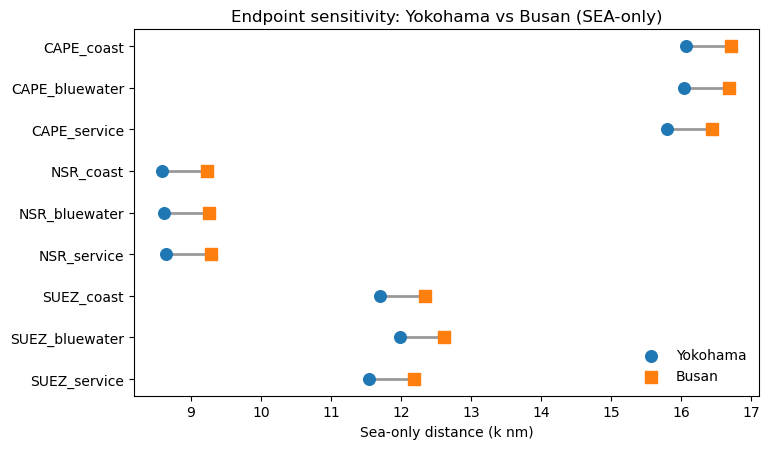

In [22]:
# ----------------------------
# 5) Tables for endpoint sensitivity
# ----------------------------

# (a) Busan per-variant SEA-only distances
busan_per_variant = (
    sea_bus_full[["corridor","variant","distance_knm"]]
    .rename(columns={"distance_knm":"Sea-only (k nm)"})
    .sort_values(["corridor","variant"])
)

# (b) Busan corridor medians across variants
busan_corr_meds = (
    sea_bus_full.groupby("corridor", observed=True)["distance_knm"]
    .agg(Median="median", Min="min", Max="max", std="std")
    .reset_index()
)
busan_corr_meds["CV (%)"] = 100.0 * busan_corr_meds["std"] / busan_corr_meds["Median"]
busan_corr_meds = busan_corr_meds.rename(columns={
    "Median":"Median (k nm)", "Min":"Min (k nm)", "Max":"Max (k nm)"
})
busan_corr_meds["corridor"] = pd.Categorical(busan_corr_meds["corridor"], CORRIDOR_ORDER, ordered=True)
busan_corr_meds = busan_corr_meds.sort_values("corridor")

# (c) Delta vs baseline destination (corridor medians)
yok_corr_meds = (
    sea_yok_full.groupby("corridor", observed=True)["distance_knm"]
    .median().reset_index().rename(columns={"distance_knm":"Yokohama (k nm)"})
)
bus_corr_meds = (
    sea_bus_full.groupby("corridor", observed=True)["distance_knm"]
    .median().reset_index().rename(columns={"distance_knm":"Busan (k nm)"})
)

dest_delta = pd.merge(yok_corr_meds, bus_corr_meds, on="corridor")
dest_delta["Delta (k nm)"] = dest_delta["Busan (k nm)"] - dest_delta["Yokohama (k nm)"]
dest_delta["Delta (%)"] = 100.0 * dest_delta["Delta (k nm)"] / dest_delta["Yokohama (k nm)"]
dest_delta["corridor"] = pd.Categorical(dest_delta["corridor"], CORRIDOR_ORDER, ordered=True)
dest_delta = dest_delta.sort_values("corridor")


# ----------------------------
# 6) Figure A: Endpoint sensitivity dumbbell (SEA-only)
# ----------------------------
plt.figure(figsize=(7.8, 4.6))
ypos = np.arange(len(delta_df_tbl))

x_yok = delta_df_tbl["Yokohama (k nm)"].values
x_bus = delta_df_tbl["Busan (k nm)"].values

# connectors
for i in range(len(delta_df_tbl)):
    plt.plot([x_yok[i], x_bus[i]], [i, i], color="0.6", linewidth=2, zorder=1)

# fixed colors for legend sanity
plt.scatter(x_yok, ypos, marker="o", s=70, color="C0", label="Yokohama", zorder=3)
plt.scatter(x_bus, ypos, marker="s", s=70, color="C1", label="Busan", zorder=3)

labels = [f"{r.corridor}_{r.variant}" for r in delta_df_tbl.itertuples()]
plt.yticks(ypos, labels)
plt.xlabel("Sea-only distance (k nm)")
plt.title("Endpoint sensitivity: Yokohama vs Busan (SEA-only)")
plt.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "DEST_endpoint_sensitivity_dumbbell.png"), dpi=300)
plt.show()

,corridor,dist_med_knm,days_med_corr,days_med_equal
0,SUEZ,11.703988,33.632150,34.833298
1,NSR,8.612982,28.709940,25.633875
2,CAPE,16.051906,47.773529,47.773529


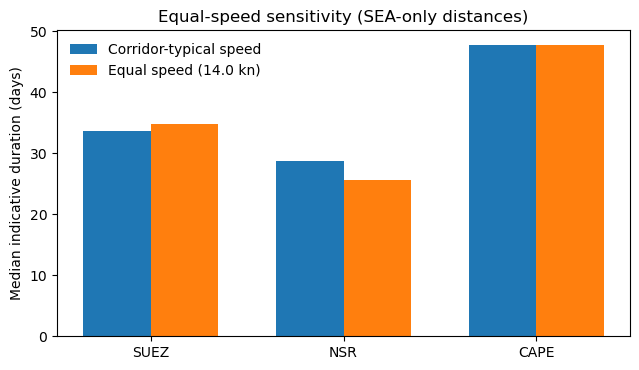

Case 4 outputs written to:
  DEST_BUSAN_SEA_corridor_medians.tex
  DEST_BUSAN_SEA_per_variant.tex
  DEST_DELTA_vs_baseline_SEA.tex
  DEST_endpoint_sensitivity_dumbbell.png
  BASELINE_equal_speed_days_bars.png


In [23]:
# ----------------------------
# 7) Equal-speed sensitivity (apples-to-apples)
#     Uses SEA-only Yokohama distances
# ----------------------------
sea_yok_eq = sea_yok_full.copy()

sea_yok_eq["speed_corridor"] = sea_yok_eq["corridor"].map(SPEEDS)
sea_yok_eq["time_days_corridor_speed"] = (sea_yok_eq["distance_nm"] / sea_yok_eq["speed_corridor"]) / 24.0
sea_yok_eq["time_days_equal_speed"]    = (sea_yok_eq["distance_nm"] / EQUAL_SPEED) / 24.0

eq_summary = (
    sea_yok_eq.groupby("corridor", observed=True)
    .agg(dist_med_knm=("distance_nm", lambda x: np.median(x)/1000.0),
         days_med_corr=("time_days_corridor_speed","median"),
         days_med_equal=("time_days_equal_speed","median"))
    .reindex(CORRIDOR_ORDER)
    .reset_index()
)

display(eq_summary)

# Figure B: corridor median days (corridor speed vs equal speed)
plt.figure(figsize=(6.5, 3.8))
x = np.arange(len(CORRIDOR_ORDER))
w = 0.35

plt.bar(x - w/2, eq_summary["days_med_corr"], width=w, label="Corridor-typical speed")
plt.bar(x + w/2, eq_summary["days_med_equal"], width=w, label=f"Equal speed ({EQUAL_SPEED} kn)")
plt.xticks(x, CORRIDOR_ORDER)
plt.ylabel("Median indicative duration (days)")
plt.title("Equal-speed sensitivity (SEA-only distances)")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "BASELINE_equal_speed_days_bars.png"), dpi=300)
plt.show()

print("Case 4 outputs written to:")
print("  DEST_BUSAN_SEA_corridor_medians.tex")
print("  DEST_BUSAN_SEA_per_variant.tex")
print("  DEST_DELTA_vs_baseline_SEA.tex")
print("  DEST_endpoint_sensitivity_dumbbell.png")
print("  BASELINE_equal_speed_days_bars.png")

In [25]:
routes_sea

{'SUEZ_VAR1_service': [(51.95, 4.14),
  (51.835844, 4.04758799999999),
  (51.85732, 3.9966019999999958),
  (52, 3.9000000000000057),
  (51.659619, 3.559618999999998),
  (51.5, 3.4000000000000057),
  (51.178984, 2.356698999999992),
  (51.1, 2.0999999999999943),
  (50.988387, 1.8131950000000074),
  (50.892845, 1.5676870000000065),
  (50.849032, 1.441365999999988),
  (50.760438, 1.3963660000000004),
  (50.563512, 1.117256999999995),
  (50.518891, 0.9227380000000096),
  (50.563512, 1.117256999999995),
  (50.420874, 0.49638899999999353),
  (50.375048, 0.2969200000000001),
  (50.260643, -0.33791400000001204),
  (50.260219, -0.3402680000000089),
  (50.255871, -0.3643940000000043),
  (50.196513, -0.5459590000000105),
  (50.155459, -0.6715389999999957),
  (49.95, -1.3000000000000114),
  (49.895072, -1.479770000000002),
  (49.838248, -1.665742999999992),
  (49.75639, -1.93365),
  (49.738559, -1.9920060000000035),
  (49.616376, -2.3918899999999894),
  (49.370363, -3.197043000000008),
  (49.129249

### Create Corridor Waypoints GeoJSON ArcGIS -- Move Later to seperate notebook

In [26]:
import json
from pathlib import Path

# Example: routes_sea contains lists of (lat, lon) pairs for each scenario
# e.g. routes_sea["SUEZ_VAR1_service"], routes_sea["NSR_VAR1_service"], ...

def to_geojson_line(coords_lat_lon):
    # ArcGIS expects lon, lat
    coords_lon_lat = [[lon, lat] for (lat, lon) in coords_lat_lon]
    return {
        "type": "Feature",
        "geometry": {
            "type": "LineString",
            "coordinates": coords_lon_lat,
        },
        "properties": {},
    }

features = []

features.append({
    "type": "Feature",
    "geometry": {
        "type": "LineString",
        "coordinates": [[lon, lat] for (lat, lon) in routes_sea["SUEZ_VAR1_service"]],
    },
    "properties": {"corridor": "SUEZ"}
})

features.append({
    "type": "Feature",
    "geometry": {
        "type": "LineString",
        "coordinates": [[lon, lat] for (lat, lon) in routes_sea["CAPE_VAR1_service"]],
    },
    "properties": {"corridor": "CAPE"}
})

features.append({
    "type": "Feature",
    "geometry": {
        "type": "LineString",
        "coordinates": [[lon, lat] for (lat, lon) in routes_sea["NSR_VAR1_service"]],
    },
    "properties": {"corridor": "NSR"}
})

geo = {"type": "FeatureCollection", "features": features}

out_path = Path("data/corridor_overview_routes.geojson")
out_path.parent.mkdir(parents=True, exist_ok=True)
with out_path.open("w", encoding="utf-8") as f:
    json.dump(geo, f)
print("Wrote", out_path)

Wrote data/corridor_overview_routes.geojson


In [27]:
ports = {
    "Rotterdam": (51.95, 4.14),
    "Yokohama": (35.45, 139.65),
}

port_features = []
for name, (lat, lon) in ports.items():
    port_features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [lon, lat],
        },
        "properties": {"name": name},
    })

ports_geo = {"type": "FeatureCollection", "features": port_features}
Path("data/corridor_overview_ports.geojson").write_text(json.dumps(ports_geo), encoding="utf-8")

282

In [ ]:
### Diagnosing issues with the visualization of route per corridor 

In [30]:
import json
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import searoute as sr
from geopy.distance import geodesic  # make sure this is imported

# --------------------------------------------------
# 1. Choose which scenario to use per corridor
# --------------------------------------------------
CORRIDOR_EXAMPLES = {
    "SUEZ": "SUEZ_VAR1_service",
    "NSR":  "NSR_VAR1_service",
    "CAPE": "CAPE_VAR1_service",
}

OUTDIR = Path("outputs")
GJDIR  = OUTDIR / "geojson_routes"
FIGDIR = OUTDIR / "quicklook_figures"
GJDIR.mkdir(parents=True, exist_ok=True)
FIGDIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# 2. Helper: build one sea-only polyline from macro waypoints
# --------------------------------------------------
def build_seaonly_polyline_latlon(waypoints_latlon):
    """
    waypoints_latlon: list of (lat, lon)
    returns:
        poly_latlon: list of (lat, lon) along full route
        total_nm:    total sea-only distance [nm]
    """
    poly_latlon = [waypoints_latlon[0]]
    total_nm = 0.0

    for (lat1, lon1), (lat2, lon2) in zip(waypoints_latlon[:-1], waypoints_latlon[1:]):
        # searoute expects origin/destination as (lon, lat)
        route = sr.searoute(
            origin=(lon1, lat1),
            destination=(lon2, lat2),
            units="nm",              # so returned length is in nautical miles
        )

        coords_lonlat = route["geometry"]["coordinates"]  # [ [lon, lat], ... ]
        props = route.get("properties", {})

        # 1) Preferred: use length from properties
        if "length_nm" in props:
            leg_nm = props["length_nm"]
        elif "length" in props:
            leg_nm = props["length"]     # already in nm because units="nm"
        else:
            # 2) Fallback: compute from geometry using geopy
            leg_nm = 0.0
            for (lon_a, lat_a), (lon_b, lat_b) in zip(coords_lonlat[:-1],
                                                      coords_lonlat[1:]):
                leg_nm += geodesic((lat_a, lon_a), (lat_b, lon_b)).nautical

        # convert lon,lat -> lat,lon for our own storage
        leg_latlon = [(lat, lon) for lon, lat in coords_lonlat]

        poly_latlon.extend(leg_latlon[1:])  # avoid duplicating first point
        total_nm += leg_nm

    return poly_latlon, total_nm

# --------------------------------------------------
# 3. Build and save one example route per corridor
# --------------------------------------------------
features = []

for corridor, scen_key in CORRIDOR_EXAMPLES.items():
    if scen_key not in SCENARIOS:
        raise KeyError(f"Scenario {scen_key!r} not found in SCENARIOS")

    wpts_latlon = SCENARIOS[scen_key]

    poly_latlon, total_nm = build_seaonly_polyline_latlon(wpts_latlon)

    # GeoJSON Feature: geometry in lon,lat
    coords_lonlat = [[lon, lat] for (lat, lon) in poly_latlon]
    feature = {
        "type": "Feature",
        "properties": {
            "corridor": corridor,
            "scenario": scen_key,
            "length_nm": float(total_nm),
        },
        "geometry": {
            "type": "LineString",
            "coordinates": coords_lonlat,
        },
    }

    # Save per-corridor GeoJSON
    gj_path = GJDIR / f"route_example_{corridor}.geojson"
    with gj_path.open("w", encoding="utf-8") as f:
        json.dump({"type": "FeatureCollection", "features": [feature]}, f, indent=2)
    print(f"{corridor}: {total_nm/1000:.2f} k nm  → saved to {gj_path}")

    # Quick-look plot
    lats = [lat for lat, lon in poly_latlon]
    lons = [lon for lat, lon in poly_latlon]

    plt.figure(figsize=(5, 4))
    plt.plot(lons, lats, "-")
    plt.scatter([w[1] for w in wpts_latlon], [w[0] for w in wpts_latlon], s=20)
    plt.title(f"{corridor} example route ({scen_key})")
    plt.xlabel("Longitude (°)")
    plt.ylabel("Latitude (°)")
    plt.tight_layout()
    fig_path = FIGDIR / f"route_example_{corridor}.png"
    plt.savefig(fig_path, dpi=200)
    plt.close()
    print(f"  quick-look figure saved to {fig_path}")

    features.append(feature)

# Combined file with all three
combined_path = GJDIR / "route_examples_all_corridors.geojson"
with combined_path.open("w", encoding="utf-8") as f:
    json.dump({"type": "FeatureCollection", "features": features}, f, indent=2)

print("\nCombined GeoJSON with all example routes:", combined_path)

SUEZ: 15.29 k nm  → saved to outputs/geojson_routes/route_example_SUEZ.geojson
  quick-look figure saved to outputs/quicklook_figures/route_example_SUEZ.png
NSR: 28.64 k nm  → saved to outputs/geojson_routes/route_example_NSR.geojson
  quick-look figure saved to outputs/quicklook_figures/route_example_NSR.png
CAPE: 20.96 k nm  → saved to outputs/geojson_routes/route_example_CAPE.geojson
  quick-look figure saved to outputs/quicklook_figures/route_example_CAPE.png

Combined GeoJSON with all example routes: outputs/geojson_routes/route_examples_all_corridors.geojson


In [32]:
import json

# 1) Get your A* sea-only NSR polyline (already navigable & validated)
nsr_coords = routes_sea["NSR_VAR1_service"]   # [(lon, lat), (lon, lat), ...]

# 2) Normalise longitudes into [-180, 180] for nice plotting
def norm_lon(lon):
    return ((lon + 180) % 360) - 180

nsr_coords_norm = [(norm_lon(lon), lat) for lon, lat in nsr_coords]

# 3) Build GeoJSON FeatureCollection
nsr_feature = {
    "type": "Feature",
    "properties": {
        "corridor": "NSR",
        "scenario": "NSR_VAR1_service"
    },
    "geometry": {
        "type": "LineString",
        "coordinates": nsr_coords_norm  # [ [lon,lat], ... ]
    }
}

fc = {
    "type": "FeatureCollection",
    "features": [nsr_feature]
}

with open("nsr_route_overview.geojson", "w", encoding="utf-8") as f:
    json.dump(fc, f)

In [33]:
import json

# Very simplified NSR macro corridor (edit these to match what you like visually)
nsr_macro = [
    (4.14, 51.95),    # Rotterdam
    (20.0, 70.0),     # off North Norway
    (60.0, 71.0),     # Kara Sea
    (100.0, 77.0),    # Laptev/East Siberian
    (150.0, 72.0),    # Chukchi
    (-170.0, 64.5),   # Bering Strait (west side)
    (139.65, 35.45),  # Yokohama
]

def norm_lon(lon):
    return ((lon + 180) % 360) - 180

coords = [(norm_lon(lon), lat) for lon, lat in nsr_macro]

nsr_feature = {
    "type": "Feature",
    "properties": {"corridor": "NSR"},
    "geometry": {"type": "LineString", "coordinates": coords}
}

fc = {"type": "FeatureCollection", "features": [nsr_feature]}

with open("nsr_route_overview_schematic.geojson", "w", encoding="utf-8") as f:
    json.dump(fc, f)

In [34]:
import json
import numpy as np

in_path = "nsr_route_overview.geojson"   # your current broken file
out_path = "corridor_overview_routes_nsr_fixed.geojson"

with open(in_path, "r", encoding="utf-8") as f:
    data = json.load(f)

for feat in data.get("features", []):
    geom = feat.get("geometry", {})
    if geom.get("type") != "LineString":
        continue

    new_coords = []
    for lat, lon in geom["coordinates"]:
        # swap back to [lon, lat]
        lon_norm = ((lon + 180.0) % 360.0) - 180.0  # wrap into [-180, 180]
        new_coords.append([lon_norm, lat])

    geom["coordinates"] = new_coords

with open(out_path, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2)

print(f"Fixed NSR route written to {out_path}")

Fixed NSR route written to corridor_overview_routes_nsr_fixed.geojson


In [36]:
import json
import os
import searoute as sr

# --------------------------------------------------
# 0. Helper: normalise and validate lon/lat
# --------------------------------------------------
def normalize_lon(lon):
    """
    Wrap longitude into [-180, 180].
    """
    return ((lon + 180) % 360) - 180

def clean_waypoints(waypoints, name=""):
    """
    Take a list of (lon, lat) and:
      - normalise lon into [-180, 180]
      - check that lat in [-90, 90]
    Return cleaned list.
    """
    cleaned = []
    for i, (lon, lat) in enumerate(waypoints):
        lon_norm = normalize_lon(lon)
        if not (-90.0 <= lat <= 90.0):
            raise ValueError(f"{name}: invalid latitude at index {i}: {lat}")
        cleaned.append((lon_norm, lat))
    return cleaned

# Quick diagnostic (optional):
for key, wpts in SCENARIOS.items():
    for j, (lon, lat) in enumerate(wpts):
        if abs(lon) > 180 or abs(lat) > 90:
            print("Out-of-range macro waypoint:",
                  key, j, "lon=", lon, "lat=", lat)


# --------------------------------------------------
# 1. Pick representative scenarios per corridor
#    (adjust names if your keys differ)
# --------------------------------------------------
REPRESENTATIVE_SCENARIOS = {
    "SUEZ": "SUEZ_VAR1_service",
    "NSR":  "NSR_VAR1_service",
    "CAPE": "CAPE_VAR1_service",
}

# --------------------------------------------------
# 2. Build corridor polylines using searoute
# --------------------------------------------------
def build_corridor_polyline(waypoints, label=""):
    """
    Given cleaned (lon, lat) macro waypoints, call searoute
    for each leg and stitch into one LineString.
    """
    full_coords = []
    first_leg = True

    for (lon1, lat1), (lon2, lat2) in zip(waypoints[:-1], waypoints[1:]):
        route = sr.searoute(
            origin=(lon1, lat1),
            destination=(lon2, lat2),
            units="nm",
            append_orig_dest=True,   # include both endpoints
            # no restrictions, no custom M/P, keep it simple
        )

        seg_coords = route["geometry"]["coordinates"]  # [[lon, lat], ...]

        if first_leg:
            full_coords.extend(seg_coords)
            first_leg = False
        else:
            # avoid duplicating first point of each segment
            full_coords.extend(seg_coords[1:])

    return full_coords

features = []

for corridor, scen_key in REPRESENTATIVE_SCENARIOS.items():
    if scen_key not in SCENARIOS:
        raise KeyError(f"Scenario {scen_key} not found in SCENARIOS")

    # 1) clean waypoints (fix lon range; validate lat)
    wpts_raw = SCENARIOS[scen_key]
    wpts_clean = clean_waypoints(wpts_raw, name=scen_key)

    # 2) build nice sea-only line
    coords = build_corridor_polyline(wpts_clean, label=scen_key)

    features.append({
        "type": "Feature",
        "properties": {
            "corridor": corridor,
            "scenario": scen_key,
        },
        "geometry": {
            "type": "LineString",
            "coordinates": coords  # [lon, lat]
        }
    })

fc = {
    "type": "FeatureCollection",
    "features": features
}

os.makedirs("figures_geojson", exist_ok=True)
out_path = os.path.join("figures_geojson", "corridor_overview_simple.geojson")

with open(out_path, "w", encoding="utf-8") as f:
    json.dump(fc, f, indent=2)

print("Written clean corridor GeoJSON to:")
print(" ", out_path)
print("Corridors:", [f["properties"]["corridor"] for f in features])

Out-of-range macro waypoint: SUEZ_VAR1_service 6 lon= 1.2 lat= 103.5
Out-of-range macro waypoint: SUEZ_VAR1_service 7 lon= 15.0 lat= 120.0
Out-of-range macro waypoint: SUEZ_VAR1_service 8 lon= 35.0 lat= 140.0
Out-of-range macro waypoint: SUEZ_VAR1_service 9 lon= 35.45 lat= 139.65
Out-of-range macro waypoint: SUEZ_VAR2_bluewater 6 lon= 1.2 lat= 103.5
Out-of-range macro waypoint: SUEZ_VAR2_bluewater 7 lon= 20.0 lat= 130.0
Out-of-range macro waypoint: SUEZ_VAR2_bluewater 8 lon= 35.0 lat= 140.0
Out-of-range macro waypoint: SUEZ_VAR2_bluewater 9 lon= 35.45 lat= 139.65
Out-of-range macro waypoint: SUEZ_VAR3_coast 9 lon= 1.2 lat= 103.5
Out-of-range macro waypoint: SUEZ_VAR3_coast 10 lon= 22.0 lat= 121.0
Out-of-range macro waypoint: SUEZ_VAR3_coast 11 lon= 35.0 lat= 140.0
Out-of-range macro waypoint: SUEZ_VAR3_coast 12 lon= 35.45 lat= 139.65
Out-of-range macro waypoint: CAPE_VAR1_service 6 lon= 1.2 lat= 103.5
Out-of-range macro waypoint: CAPE_VAR1_service 7 lon= 15.0 lat= 120.0
Out-of-range ma

ValueError: SUEZ_VAR1_service: invalid latitude at index 6: 103.5

In [37]:
print("SUEZ_VAR1_service[6] =", SCENARIOS["SUEZ_VAR1_service"][6])

SUEZ_VAR1_service[6] = (1.2, 103.5)


In [38]:
SCENARIOS

{'SUEZ_VAR1_service': [(51.95, 4.14),
  (50.5, 1.0),
  (36.0, -5.6),
  (30.0, 32.6),
  (12.6, 43.3),
  (6.0, 80.6),
  (1.2, 103.5),
  (15.0, 120.0),
  (35.0, 140.0),
  (35.45, 139.65)],
 'SUEZ_VAR2_bluewater': [(51.95, 4.14),
  (48.0, -10.0),
  (36.0, -5.6),
  (30.0, 32.6),
  (12.6, 43.3),
  (0.0, 70.0),
  (1.2, 103.5),
  (20.0, 130.0),
  (35.0, 140.0),
  (35.45, 139.65)],
 'SUEZ_VAR3_coast': [(51.95, 4.14),
  (50.5, 1.0),
  (36.0, -5.6),
  (33.5, 20.0),
  (30.0, 32.6),
  (20.0, 39.0),
  (12.6, 43.3),
  (14.0, 55.0),
  (6.0, 80.6),
  (1.2, 103.5),
  (22.0, 121.0),
  (35.0, 140.0),
  (35.45, 139.65)],
 'CAPE_VAR1_service': [(51.95, 4.14),
  (36.0, -5.6),
  (14.7, -17.5),
  (-34.0, 18.5),
  (-20.0, 40.0),
  (0.0, 70.0),
  (1.2, 103.5),
  (15.0, 120.0),
  (35.0, 140.0),
  (35.45, 139.65)],
 'CAPE_VAR2_bluewater': [(51.95, 4.14),
  (30.0, -20.0),
  (-10.0, -25.0),
  (-34.0, 18.5),
  (-30.0, 60.0),
  (1.2, 103.5),
  (20.0, 130.0),
  (35.0, 140.0),
  (35.45, 139.65)],
 'CAPE_VAR3_coast': [(5

In [39]:
import json

# 1) Your NSR service variant waypoints (as given): (lat, lon)
NSR_VAR1_service_latlon = [
    (51.95, 4.14),    # Rotterdam
    (71.0, 25.0),     # Barents / near Norway
    (70.5, 58.0),     # Kara Sea region
    (76.0, 102.0),    # Laptev Sea region
    (72.0, 160.0),    # East Siberian / Chukchi region
    (66.0, -169.0),   # Bering Strait region
    (43.0, 150.0),    # NW Pacific
    (35.0, 140.0),    # Off Honshu
    (35.45, 139.65),  # Yokohama
]

# 2) Convert (lat, lon) -> [lon, lat] for GeoJSON
NSR_VAR1_service_lonlat = [
    [lon, lat] for (lat, lon) in NSR_VAR1_service_latlon
]

# 3) Build a minimal GeoJSON FeatureCollection
nsr_feature = {
    "type": "Feature",
    "properties": {
        "corridor": "NSR",
        "scenario": "NSR_VAR1_service",
        "type": "macro_waypoints_chain"
    },
    "geometry": {
        "type": "LineString",
        "coordinates": NSR_VAR1_service_lonlat,
    },
}

nsr_geojson = {
    "type": "FeatureCollection",
    "features": [nsr_feature],
}

# 4) Write to file
out_path = "NSR_VAR1_service_macro.geojson"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(nsr_geojson, f, indent=2)

print(f"Written: {out_path}")

Written: NSR_VAR1_service_macro.geojson


In [40]:
import folium

# ------------------------------
# 1) Define the three NSR segments (sketch)
#    Coordinates are [lon, lat] (GeoJSON standard)
# ------------------------------
nsr_west = {
    "type": "Feature",
    "properties": {"corridor": "NSR", "segment": "west"},
    "geometry": {
        "type": "LineString",
        "coordinates": [
            [4.14, 51.95],
            [4.5, 54.0],
            [5.0, 57.0],
            [8.0, 61.0],
            [15.0, 66.0],
            [25.0, 70.0],
            [35.0, 72.0],
            [50.0, 73.0],
            [65.0, 74.0],
            [80.0, 75.0],
            [95.0, 76.0],
            [115.0, 76.0],
            [135.0, 75.0],
            [150.0, 73.0],
            [170.0, 70.0],
            [179.0, 69.0]
        ]
    }
}

nsr_central = {
    "type": "Feature",
    "properties": {"corridor": "NSR", "segment": "central"},
    "geometry": {
        "type": "LineString",
        "coordinates": [
            [179.0, 69.0],
            [175.0, 66.0],
            [170.0, 63.0],
            [165.0, 60.0],
            [160.0, 56.0],
            [155.0, 52.0],
            [150.0, 48.0],
            [147.0, 44.0],
            [145.0, 41.0]
        ]
    }
}

nsr_east = {
    "type": "Feature",
    "properties": {"corridor": "NSR", "segment": "east"},
    "geometry": {
        "type": "LineString",
        "coordinates": [
            [145.0, 41.0],
            [142.0, 38.0],
            [141.0, 36.0],
            [140.0, 35.5],
            [139.8, 35.4],
            [139.65, 35.45]  # Yokohama
        ]
    }
}

nsr_collection = {
    "type": "FeatureCollection",
    "features": [nsr_west, nsr_central, nsr_east]
}

# ------------------------------
# 2) Build the folium map
# ------------------------------

# Rough center somewhere over the Arctic / N. Pacific
m = folium.Map(location=[65, 100], zoom_start=2, tiles="CartoDB positron")

def style_function(feature):
    return {
        "color": "#0072B2",  # blue-ish
        "weight": 3,
        "opacity": 0.9
    }

folium.GeoJson(
    nsr_collection,
    name="NSR (schematic)",
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(fields=["corridor", "segment"])
).add_to(m)

folium.LayerControl().add_to(m)

# Option A: show directly in notebook
m

# Option B: save as HTML
#m.save("nsr_schematic_map.html")

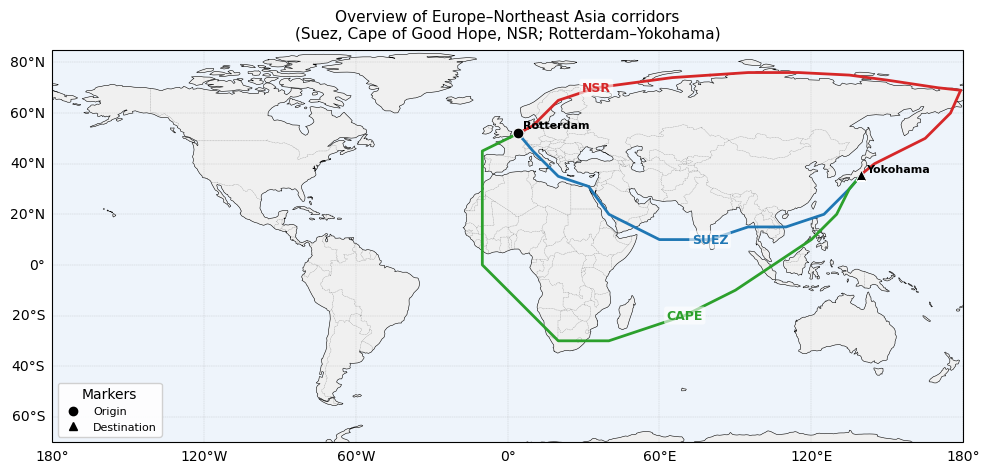

Saved: figures/corridor_overview_world.png


In [43]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

# ==========================
# 1. Define key points
# ==========================
# (lon, lat)
ROTTERDAM = (4.14, 51.95)
YOKOHAMA  = (139.65, 35.45)

# ==========================
# 2. Define corridor polylines
#    >>> Replace these with YOUR final coordinates <<<
#    Each value is a list of segments; each segment is a list of (lon, lat) pairs.
# ==========================

# --- Example schematic SUEZ (replace with your route) ---
suez_segments = [
    [
        (ROTTERDAM[0], ROTTERDAM[1]),
        (10, 45),     # Med
        (20, 35),     # Eastern Med
        (32, 31),     # Suez area
        (40, 20),     # Red Sea / Gulf of Aden
        (60, 10),     # Arabian Sea
        (80, 10),     # Indian Ocean
        (95, 15),     # Bay of Bengal
        (110, 15),
        (125, 20),
        (135, 30),
        (YOKOHAMA[0], YOKOHAMA[1]),
    ]
]

# --- Example schematic CAPE (replace with your route) ---
cape_segments = [
    [
        (ROTTERDAM[0], ROTTERDAM[1]),
        (-10, 45),      # Atlantic down
        (-10, 0),       # Equator
        (10, -20),      # off West Africa
        (20, -30),      # Cape region (offshore)
        (40, -30),      # Southern Indian Ocean
        (70, -20),
        (90, -10),
        (105, 0),
        (120, 10),
        (130, 20),
        (135, 30),
        (YOKOHAMA[0], YOKOHAMA[1]),
    ]
]

# --- NSR in 2–3 segments (schematic, replace with your cleaned version) ---
nsr_segments = [
    # West / Barents to Kara/Laptev
    [
        (ROTTERDAM[0], ROTTERDAM[1]),
        (10, 55),
        (20, 65),
        (35, 70),
        (50, 72),
        (65, 74),
        (80, 75),
    ],
    # Laptev / East Siberian to Chukchi
    [
        (80, 75),
        (95, 76),
        (115, 76),
        (135, 75),
        (150, 73),
        (170, 70),
        (179, 69),
    ],
    # Bering Strait down to Yokohama (Pacific side)
    [
        (179, 69),
        (175, 60),
        (165, 50),
        (155, 45),
        (145, 40),
        (140, 36),
        (YOKOHAMA[0], YOKOHAMA[1]),
    ],
]

CORRIDOR_LINES = {
    "SUEZ": suez_segments,
    "CAPE": cape_segments,
    "NSR":  nsr_segments,
}

# ==========================
# 3. Style configuration
# ==========================

corridor_colors = {
    "SUEZ": "#1f77b4",   # blue
    "CAPE": "#2ca02c",   # green
    "NSR":  "#d62728",   # red
}

start_marker_style = dict(marker="o", s=60, edgecolors="white", linewidths=0.7, zorder=6)
end_marker_style   = dict(marker="^", s=60, edgecolors="white", linewidths=0.7, zorder=6)

# ==========================
# 4. Plot
# ==========================

fig = plt.figure(figsize=(10, 5.2))
proj = ccrs.PlateCarree()
ax = plt.axes(projection=proj)

# Global extent with a bit of padding
ax.set_global()
ax.set_extent([-180, 180, -70, 85], crs=proj)

# Background: clean and muted
ax.add_feature(cfeature.OCEAN.with_scale("110m"), facecolor="#eef4fb", zorder=0)
ax.add_feature(cfeature.LAND.with_scale("110m"),  facecolor="#f0f0f0", zorder=0)
ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.4, zorder=1)
ax.add_feature(cfeature.BORDERS.with_scale("110m"),  linewidth=0.2, linestyle=":", zorder=1)

# Subtle gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", color="gray", alpha=0.4)
gl.top_labels = False
gl.right_labels = False

# Plot corridors
for name, segments in CORRIDOR_LINES.items():
    color = corridor_colors[name]
    for seg in segments:
        lons, lats = zip(*seg)
        ax.plot(
            lons, lats,
            transform=proj,
            color=color,
            linewidth=2.0,
            solid_capstyle="round",
            zorder=3,
            label=name if seg is segments[0] else None,  # only label once per corridor
        )

# --- Add on-map labels for corridors (one per corridor) ---
for name, segments in CORRIDOR_LINES.items():
    color = corridor_colors[name]
    # pick middle point of the first segment
    seg = segments[0]
    mid_idx = len(seg) // 2
    mid_lon, mid_lat = seg[mid_idx]

    ax.text(
        mid_lon, mid_lat,
        name,                      # "SUEZ", "CAPE", "NSR"
        transform=proj,
        fontsize=9,
        color=color,
        weight="bold",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="none",
            alpha=0.6
        ),
        zorder=5,
    )

# Start and end markers
ax.scatter(
    ROTTERDAM[0], ROTTERDAM[1],
    transform=proj, color="black",
    **start_marker_style,
    label="Rotterdam"  # will use in legend
)

ax.scatter(
    YOKOHAMA[0], YOKOHAMA[1],
    transform=proj, color="black",
    **end_marker_style,
    label="Yokohama"
)

# Optional text labels near start/end (small offset)
ax.text(ROTTERDAM[0] + 2, ROTTERDAM[1] + 2, "Rotterdam",
        transform=proj, fontsize=8, weight="bold")
ax.text(YOKOHAMA[0] + 2, YOKOHAMA[1] + 1, "Yokohama",
        transform=proj, fontsize=8, weight="bold")

# Custom legend: corridors + start/end markers
marker_handles = [
    Line2D([0], [0], marker="o", color="black", markersize=6,
           markerfacecolor="black", linestyle="None", label="Origin"),
    Line2D([0], [0], marker="^", color="black", markersize=6,
           markerfacecolor="black", linestyle="None", label="Destination"),
]

ax.legend(
    handles=marker_handles,
    loc="lower left",
    frameon=True,
    framealpha=0.9,
    fontsize=8,
    title="Markers"
)

ax.set_title(
    "Overview of Europe–Northeast Asia corridors\n"
    "(Suez, Cape of Good Hope, NSR; Rotterdam–Yokohama)",
    fontsize=11,
    pad=8
)

plt.tight_layout()
plt.savefig("figures/corridor_overview_world.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/corridor_overview_world.png")